# Deep Learning Mid Exam – ANN Model (Car Price Prediction)

Nama: Syaqila Najwa Amalia Hambali

NIM: 2802488481

Objective:

The objective of this project is to develop an Artificial Neural Network (ANN) model to estimate the selling price of used cars based on vehicle specifications and transaction information.

The dataset contains both numerical and categorical features, therefore several preprocessing steps are required before training the model.

# 1A

EDA + preprocessing + split

## **Library**

In [84]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

In [85]:
df = pd.read_parquet("1B.parquet")
df.head()

,Sales_ID,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
0,1933,Maruti,2013,4500.00,41800,South,Florida,Orlando,Petrol,Individual,Manual,First_Owner,18.6,1197,85.8,114Nm@ 4000rpm,5,Y
1,4901,Ford,2004,4000.00,93415,East,Massachusetts,Abington,Diesel,Dealer,Manual,First_Owner,13.1,2499,141.0,330Nm@ 1800rpm,7,N
2,2802,Honda,2017,8199.99,12000,South,Arkansas,Benton,Petrol,Individual,Manual,First_Owner,17.5,1199,88.7,110Nm@ 4800rpm,5,N
3,7949,Maruti,2016,6750.00,108000,East,New York,East Massapequa,Diesel,Dealer,Manual,First_Owner,23.65,1248,88.5,200Nm@ 1750rpm,5,N
4,966,Maruti,2019,6750.00,5000,Central,Illinois,Chicago,Petrol,Individual,Automatic,First_Owner,21.4,1197,83.1,115Nm@ 4000rpm,5,Y


#### Initial Dataset Inspection

The dataset contains information about used vehicles such as production year, mileage, fuel type, transmission type, engine capacity, torque, and selling price.

The target variable for this task is **selling_price** in USD. Before training the neural network, the dataset needs to be cleaned and transformed into a machine learning ready format.


## **Preprocessing**

In [86]:
df.shape

(2000, 18)

In [87]:
for col in df.columns:
    print(f'{col}= {df[col].isnull().mean()*100}')
    print("--------------------------------------")

Sales_ID= 0.0
--------------------------------------
name= 0.0
--------------------------------------
year= 0.0
--------------------------------------
selling_price= 0.1
--------------------------------------
km_driven= 0.0
--------------------------------------
Region= 0.0
--------------------------------------
State or Province= 0.0
--------------------------------------
City= 0.0
--------------------------------------
fuel= 0.0
--------------------------------------
seller_type= 0.0
--------------------------------------
transmission= 0.0
--------------------------------------
owner= 0.0
--------------------------------------
mileage= 0.0
--------------------------------------
engine= 0.0
--------------------------------------
max_power= 0.0
--------------------------------------
torque= 0.0
--------------------------------------
seats= 0.0
--------------------------------------
sold= 0.0
--------------------------------------


In [88]:
df.duplicated().sum()

np.int64(0)

In [89]:
df.dropna(inplace=True)

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1998 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sales_ID           1998 non-null   int64  
 1   name               1998 non-null   object 
 2   year               1998 non-null   int64  
 3   selling_price      1998 non-null   float64
 4   km_driven          1998 non-null   int64  
 5   Region             1998 non-null   object 
 6   State or Province  1998 non-null   object 
 7   City               1998 non-null   object 
 8   fuel               1998 non-null   object 
 9   seller_type        1998 non-null   object 
 10  transmission       1998 non-null   object 
 11  owner              1998 non-null   object 
 12  mileage            1998 non-null   object 
 13  engine             1998 non-null   int64  
 14  max_power          1998 non-null   float64
 15  torque             1998 non-null   object 
 16  seats              1998 non-n

In [91]:
df.columns

Index(['Sales_ID', 'name', 'year', 'selling_price', 'km_driven', 'Region',
       'State or Province', 'City', 'fuel', 'seller_type', 'transmission',
       'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'sold'],
      dtype='object')

In [92]:
df.drop(columns=['Sales_ID'], inplace=True)

## **Data Type Adjustment**

Kolom kategorikal diubah menjadi tipe string untuk memudahkan proses encoding di tahap berikutnya.

In [93]:
num = ['year','selling_price','km_driven','mileage','engine',
       'max_power','seats']
obj = ['name', 'Region', 'State or Province', 'City', 'fuel',
    'seller_type', 'transmission', 'owner', 'torque', 'sold']
y= df['selling_price']

In [94]:
df[obj]=df[obj].astype('str')

## **clean torque**

Kolom torque memiliki format yang tidak konsisten (Nm, kgm, range rpm), sehingga dilakukan ekstraksi menjadi dua fitur numerik:
- torque_Nm
- rpm_val

In [95]:
#identify non-standard format
pattern = r'Nm.*rpm|kgm.*rpm'
invalid_torque = df[~df['torque'].str.contains(pattern, case=False, na=False)]

print("Jumlah data dengan format torque tidak standar:", len(invalid_torque))

Jumlah data dengan format torque tidak standar: 14


In [96]:
# Regex ini mencari pola: (Nm diikuti rpm) ATAU (kgm diikuti rpm)
# Tanda ~ adalah negasi (NOT)
pattern = r'Nm.*rpm|kgm.*rpm'

# Memfilter dataframe untuk yang TIDAK mengandung pola tersebut
outliers = df[~df['torque'].str.contains(pattern, case=False, na=False, regex=True)]

# Menampilkan nilai unik agar Anda bisa melihat formatnya tanpa duplikat
unique_outliers = outliers['torque'].unique()

print(f"Ada {len(unique_outliers)} format unik yang tidak sesuai pola:")
for format_unik in unique_outliers:
    print(format_unik)

Ada 3 format unik yang tidak sesuai pola:
400Nm
190Nm@ 2000-3000
135.4Nm@ 2500


In [97]:
import re

def clean_torque(text):
    text = str(text).lower().replace(',', '')

    # extract torque
    torque_match = re.search(r'(\d+\.?\d*)', text)
    torque = float(torque_match.group(1)) if torque_match else np.nan

    # convert kgm to Nm
    if 'kgm' in text and pd.notna(torque):
        torque = torque * 9.80665

    # extract rpm
    range_match = re.search(r'(?:@|at)[^\d]*(\d+)[-\s~]+(\d+)', text)

    if range_match:
        rpm = (float(range_match.group(1)) + float(range_match.group(2))) / 2
    else:
        single_match = re.search(r'(?:@|at)[^\d]*(\d+)', text)  # ✅ FIX DI SINI
        if single_match:
            rpm = float(single_match.group(1))
        else:
            rpm_fallback = re.search(r'(\d+)\s*rpm', text)
            rpm = float(rpm_fallback.group(1)) if rpm_fallback else np.nan

    return pd.Series([torque, rpm])

In [98]:
#terapin ke DataFrame
df[['torque_Nm', 'rpm_val']] = df['torque'].apply(clean_torque)

#nampilin hasil
print(df[['torque', 'torque_Nm', 'rpm_val']].head(20))

                  torque   torque_Nm  rpm_val
0         114Nm@ 4000rpm   114.00000   4000.0
1         330Nm@ 1800rpm   330.00000   1800.0
2         110Nm@ 4800rpm   110.00000   4800.0
3         200Nm@ 1750rpm   200.00000   1750.0
4         115Nm@ 4000rpm   115.00000   4000.0
5         360Nm@ 2000rpm   360.00000   2000.0
6   145@ 4,100(kgm@ rpm)  1421.96425   4100.0
7         112Nm@ 4000rpm   112.00000   4000.0
8         200Nm@ 1750rpm   200.00000   1750.0
9          72Nm@ 4386rpm    72.00000   4386.0
10         90Nm@ 3500rpm    90.00000   3500.0
11     113.75nm@ 4000rpm   113.75000   4000.0
12        110Nm@ 3750rpm   110.00000   3750.0
13   200Nm@ 1400-2200rpm   200.00000   1800.0
14         69Nm@ 3500rpm    69.00000   3500.0
15        190Nm@ 2000rpm   190.00000   2000.0
16         72Nm@ 4386rpm    72.00000   4386.0
17         77Nm@ 3500rpm    77.00000   3500.0
18         85Nm@ 3000rpm    85.00000   3000.0
19   205Nm@ 1750-3250rpm   205.00000   2500.0


In [99]:
# 1. Filter baris yang data MENTAH-nya mengandung 'kgm'
cek_hasil_kgm = df[df['torque'].str.contains('kgm', case=False, na=False)]

# 2. Tampilkan kolom original disandingkan dengan kolom hasil yang SUDAH CLEAN
print(f"Menampilkan sampel data kgm yang sudah terkonversi ke Nm:\n")
print(cek_hasil_kgm[['torque', 'torque_Nm', 'rpm_val']].head(20))

Menampilkan sampel data kgm yang sudah terkonversi ke Nm:

                        torque    torque_Nm  rpm_val
6         145@ 4,100(kgm@ rpm)  1421.964250   4100.0
26   24@ 1,900-2,750(kgm@ rpm)   235.359600   2325.0
40         16@ 2,000(kgm@ rpm)   156.906400   2000.0
44        7.8@ 4,500(kgm@ rpm)    76.491870   4500.0
70       12.7@ 2,700(kgm@ rpm)   124.544455   2700.0
83        9.8@ 3,000(kgm@ rpm)    96.105170   3000.0
87         16@ 2,000(kgm@ rpm)   156.906400   2000.0
92         20@ 3,750(kgm@ rpm)   196.133000   3750.0
95       11.4 kgm at 4,000 rpm   111.795810   4000.0
117      16.3@ 2,000(kgm@ rpm)   159.848395   2000.0
120  20.4@ 1400-3400(kgm@ rpm)   200.055660   2400.0
137   22.4 kgm at 1750-2750rpm   219.668960   2250.0
161      25.5@ 1,900(kgm@ rpm)   250.069575   1900.0
169  20.4@ 1400-3400(kgm@ rpm)   200.055660   2400.0
172      12.5@ 3,000(kgm@ rpm)   122.583125   3000.0
185  20.4@ 1400-3400(kgm@ rpm)   200.055660   2400.0
204  24@ 1,900-2,750(kgm@ rpm)   235.359

### **delete missing price row**

In [100]:
#cek jumlah total missing values di kolom torque_Nm & rpm_val
print("Jumlah missing values:")
print(df[['torque_Nm', 'rpm_val']].isnull().sum())

print("-" * 50)

#filter dan tampilin baris yang salah satu (atau dua"nya) kolom barunya bernilai Null
baris_null = df[df['torque_Nm'].isnull() | df['rpm_val'].isnull()]

print(f"Total ada {len(baris_null)} baris dengan nilai Null.")

#tampilin sampel data aslinya klo ada
if len(baris_null) > 0:
    print("\nMenampilkan sampel baris yang menghasilkan Null:")
    print(baris_null[['torque', 'torque_Nm', 'rpm_val']].head(20))

Jumlah missing values:
torque_Nm     0
rpm_val      12
dtype: int64
--------------------------------------------------
Total ada 12 baris dengan nilai Null.

Menampilkan sampel baris yang menghasilkan Null:
     torque  torque_Nm  rpm_val
68    400Nm      400.0      NaN
115   400Nm      400.0      NaN
346   400Nm      400.0      NaN
538   400Nm      400.0      NaN
847   400Nm      400.0      NaN
852   400Nm      400.0      NaN
997   400Nm      400.0      NaN
1094  400Nm      400.0      NaN
1582  400Nm      400.0      NaN
1658  400Nm      400.0      NaN
1718  400Nm      400.0      NaN
1789  400Nm      400.0      NaN


In [101]:
#handle missing
df['rpm_val'].fillna(df['rpm_val'].median(), inplace=True)
df['torque_Nm'].fillna(df['torque_Nm'].median(), inplace=True)

#drop column asli
df.drop(['torque'], axis=1, inplace=True)

print(f" baris setelah drop missing selling_price: {len(df)}")

 baris setelah drop missing selling_price: 1998


### Data Cleaning (Torque Feature)

Kolom torque memiliki berbagai format yang tidak konsisten, seperti:
- "190Nm@2000rpm"
- "24.5kgm@3500rpm"
- variasi lain dengan range RPM atau format berbeda

Dilakukan pengecekan menggunakan regular expression dan ditemukan adanya variasi format data.

Untuk mengatasi hal ini, dilakukan proses cleaning dengan pendekatan berikut:
- Mengekstrak nilai torque (dalam Nm)
- Mengonversi satuan kgm ke Nm
- Mengekstrak nilai RPM, termasuk menangani format range dengan mengambil nilai rata-rata

Setelah proses ekstraksi, fitur baru dibuat:
- torque_Nm
- rpm_val

Nilai missing yang muncul setelah proses cleaning ditangani menggunakan median.

Kolom asli torque kemudian dihapus untuk menghindari duplikasi informasi.

## **Data Type**

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1998 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1998 non-null   object 
 1   year               1998 non-null   int64  
 2   selling_price      1998 non-null   float64
 3   km_driven          1998 non-null   int64  
 4   Region             1998 non-null   object 
 5   State or Province  1998 non-null   object 
 6   City               1998 non-null   object 
 7   fuel               1998 non-null   object 
 8   seller_type        1998 non-null   object 
 9   transmission       1998 non-null   object 
 10  owner              1998 non-null   object 
 11  mileage            1998 non-null   object 
 12  engine             1998 non-null   int64  
 13  max_power          1998 non-null   float64
 14  seats              1998 non-null   int64  
 15  sold               1998 non-null   object 
 16  torque_Nm          1998 non-n

In [103]:
df.tail(10)

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,sold,torque_Nm,rpm_val
1990,Maruti,2013,2250.0,58343,South,Georgia,Newnan,Petrol,Trustmark_Dealer,Manual,First_Owner,21.79,998,67.05,5,N,90.0,3500.0
1991,Chevrolet,2015,3500.0,50000,South,Florida,Winter Haven,Petrol,Individual,Manual,First_Owner,18.2,1199,82.40,5,N,108.5,5000.0
1992,Lexus,2019,51500.0,20000,West,Idaho,Lewiston,Petrol,Dealer,Automatic,First_Owner,22.37,2487,214.56,5,Y,202.0,4400.0
1993,Mahindra,2015,6300.0,60000,West,Arizona,Oro Valley,Diesel,Individual,Manual,First_Owner,15.4,1997,120.00,7,N,280.0,2300.0
1994,Maruti,2017,5150.0,23000,East,Maine,Saco,Petrol,Individual,Manual,First_Owner,21.4,1197,83.10,5,N,115.0,4000.0
1995,Hyundai,2019,11250.0,3500,West,California,Coachella,Petrol,Dealer,Automatic,First_Owner,18.15,998,118.35,5,N,171.6,2750.0
1996,Isuzu,2017,12500.0,56800,West,Arizona,Prescott,Diesel,Individual,Manual,First_Owner,12.4,2499,134.00,5,N,320.0,2300.0
1997,Maruti,2015,4500.0,30000,East,New York,New York City,Petrol,Individual,Manual,First_Owner,20.4,1197,81.80,5,Y,113.0,4200.0
1998,Toyota,2009,4500.0,71000,East,New York,New York City,Petrol,Dealer,Automatic,First_Owner,12.1,2362,164.70,5,Y,224.0,4000.0
1999,Maruti,2012,2000.0,38000,West,Washington,Longview,Petrol,Dealer,Manual,Second_Owner,24.7,796,47.30,5,N,69.0,3500.0


### Handle Mileage (obj → float)

In [104]:
#Identifikasi data tidak valid
invalid_mileage = df[~df['mileage'].astype(str).str.contains(r'\d', na=False)]
print(f"Ditemukan {len(invalid_mileage)} baris tanpa angka di mileage:")
print(invalid_mileage[['name', 'year', 'mileage']])

Ditemukan 2 baris tanpa angka di mileage:
         name  year mileage
647  Mahindra  2018     nan
846      Tata  2012     nan


In [105]:
#Cleaning mileage
df['mileage'] = df['mileage'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)
df = df.dropna(subset=['mileage'])
df = df.reset_index(drop=True)
print(f"Data sekarang: {len(df)} baris")

Data sekarang: 1996 baris


In [106]:
#konversi 'mileage' dari Object ke Float
#pake regex (buat pastiin cuman angka desimal yang diambil)
df['mileage'] = df['mileage'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)

# Imputasi missing value di 'rpm_val' dengan nilai Median
rpm_median = df['rpm_val'].median()
df['rpm_val'] = df['rpm_val'].fillna(rpm_median)

#hapus kolom yang ga perlu
kolom_dibuang = ['Sales_ID', 'torque']
df = df.drop(columns=kolom_dibuang, errors='ignore')

#liat hasil akhirnya
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1996 entries, 0 to 1995
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1996 non-null   object 
 1   year               1996 non-null   int64  
 2   selling_price      1996 non-null   float64
 3   km_driven          1996 non-null   int64  
 4   Region             1996 non-null   object 
 5   State or Province  1996 non-null   object 
 6   City               1996 non-null   object 
 7   fuel               1996 non-null   object 
 8   seller_type        1996 non-null   object 
 9   transmission       1996 non-null   object 
 10  owner              1996 non-null   object 
 11  mileage            1996 non-null   float64
 12  engine             1996 non-null   int64  
 13  max_power          1996 non-null   float64
 14  seats              1996 non-null   int64  
 15  sold               1996 non-null   object 
 16  torque_Nm          1996 

### Data Type Correction

Berdasarkan hasil pengecekan tipe data, ditemukan bahwa kolom mileage masih bertipe object, padahal seharusnya numerik.

Hal ini kemungkinan disebabkan oleh adanya format string seperti satuan atau karakter tambahan.

Dilakukan proses cleaning dengan:
- Mengekstrak nilai numerik menggunakan regular expression
- Mengonversi nilai menjadi tipe float

Data yang tidak dapat dikonversi akan menjadi missing value dan dihapus dari dataset.

#### **Missing Values Handling**

Ditemukan missing values pada kolom rpm_val setelah proses feature engineering.

Nilai tersebut ditangani menggunakan median untuk menjaga kestabilan distribusi data.

#### **Feature Selection**

Beberapa kolom tidak digunakan dalam modeling:
- Sales_ID dihapus karena hanya merupakan identifier
- Kolom torque dihapus karena informasinya telah direpresentasikan oleh torque_Nm dan rpm_val

## **EDA**

EDA dilakukan untuk memahami distribusi data serta hubungan antar variabel sebelum modeling.

In [107]:
df.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats,torque_Nm,rpm_val
count,1996.000000,1996.000000,1996.000000,1996.000000,1996.000000,1996.000000,1996.000000,1996.000000,1996.000000
mean,2014.543587,6503.117320,68904.076653,19.430225,1463.515531,91.898945,5.408317,181.384760,2882.159820
std,22.616396,8325.782986,50091.800544,3.961037,501.167265,36.156279,0.950457,111.584809,954.575571
min,1999.000000,350.000000,1.000000,0.000000,624.000000,-100.000000,4.000000,48.000000,1300.000000
25%,2012.000000,2750.000000,30000.000000,16.780000,1197.000000,68.050000,5.000000,111.800000,2100.000000
50%,2015.000000,4500.000000,60000.000000,19.330000,1248.000000,82.000000,5.000000,170.000000,2400.000000
75%,2017.000000,6750.000000,90041.250000,22.320000,1582.000000,102.000000,5.000000,213.000000,4000.000000
max,3011.000000,100000.000000,475000.000000,42.000000,3604.000000,400.000000,14.000000,1421.964250,5000.000000


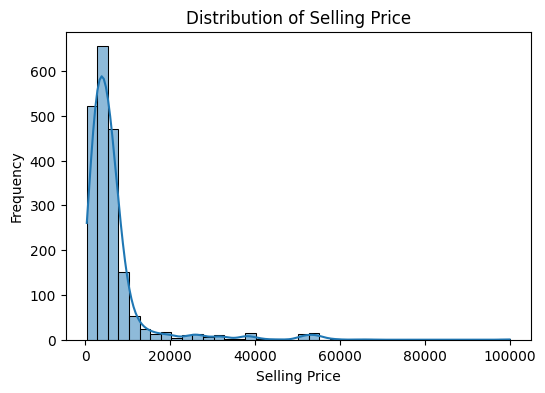

In [108]:
# distribusi harga
plt.figure(figsize=(6,4))
sns.histplot(df['selling_price'], bins=40, kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.show()

#### Distribution of Selling Price

Berdasarkan histogram, distribusi selling_price bersifat right-skewed (miring ke kanan).

Sebagian besar data berada pada rentang harga rendah, sementara terdapat sedikit data dengan harga yang sangat tinggi (long tail). Hal ini menunjukkan adanya kemungkinan outlier atau kendaraan dengan harga premium.

Distribusi yang tidak normal ini dapat mempengaruhi proses training model, sehingga perlu diperhatikan pada tahap modeling.

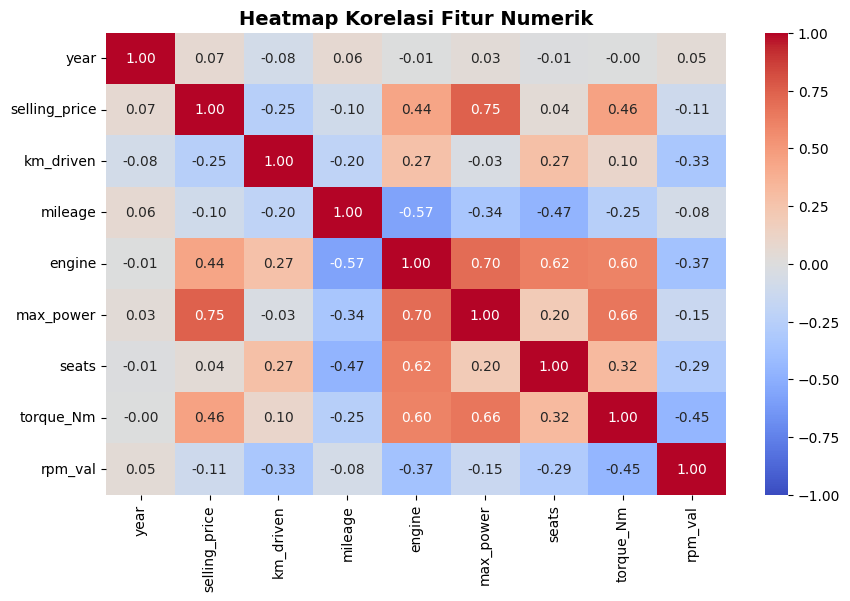

In [109]:
# correlation
plt.figure(figsize=(10,6))

#cuman ambil kolom numerik
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.show()

#### Correlation Analysis

Berdasarkan correlation matrix, ditemukan bahwa:

- max_power memiliki korelasi paling tinggi terhadap selling_price (0.75)
- torque_Nm (0.46) dan engine (0.44) juga menunjukkan hubungan positif yang cukup kuat

Hal ini menunjukkan bahwa performa mesin merupakan faktor utama yang mempengaruhi harga mobil.

Sebaliknya:
- km_driven memiliki korelasi negatif (-0.25), yang menunjukkan bahwa semakin tinggi jarak tempuh, harga mobil cenderung menurun
- mileage juga memiliki korelasi negatif, meskipun lebih lemah

Selain itu, terdapat korelasi antar fitur seperti engine dan max_power (~0.70), yang menunjukkan adanya hubungan antar fitur performa, namun masih dalam batas yang dapat diterima.

#### Insight

Dari hasil EDA dapat disimpulkan bahwa:
- Harga mobil sangat dipengaruhi oleh performa mesin
- Jarak tempuh berpengaruh negatif terhadap harga
- Tidak terdapat multicollinearity yang ekstrem

Insight ini digunakan sebagai dasar dalam pembangunan model prediksi.

## **Split & Scaling**

In [110]:
# target
y = df['selling_price'].values.reshape(-1, 1) #Reshape buat output layer

# fitur
X = df.drop(columns=['selling_price'])

In [111]:
# handle list
for col in X.columns:
    X[col] = X[col].apply(lambda x: ','.join(x) if isinstance(x, list) else x)

# convert object → string
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype(str)

# one-hot encoding
X = pd.get_dummies(X, drop_first=True)

In [112]:
# Split 70:10:20
# Pisahkan 20% untuk Test dulu
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

# Dari sisa 80%, pisahkan 10% (dari total) untuk Val.
# Rasio Val terhadap Temp adalah 10/80 = 0.125
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (1396, 1032)
Val: (200, 1032)
Test: (400, 1032)


In [113]:
#feature scaling
x_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

#shape check
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

X_train: (1396, 1032)
X_val  : (200, 1032)
X_test : (400, 1032)


In [114]:
#target scaling
y_scaler = StandardScaler()

y_train = y_scaler.fit_transform(y_train)
y_val   = y_scaler.transform(y_val)
y_test  = y_scaler.transform(y_test)

#shape check
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

y_train: (1396, 1)
y_val  : (200, 1)
y_test : (400, 1)


#### Data Splitting Result

Dataset berhasil dibagi menjadi:
- Training set: 1396 data (70%)
- Validation set: 200 data (10%)
- Test set: 400 data (20%)

Pembagian ini sudah sesuai dengan ketentuan soal.

##### **Feature Dimension**

Setelah proses encoding, jumlah fitur meningkat menjadi 1032.

Hal ini disebabkan oleh penggunaan one-hot encoding pada fitur kategorikal.

Dimensi input ini akan digunakan sebagai acuan dalam menentukan jumlah neuron pada model ANN.

# 1B

Baseline ANN: Model awal dibuat menggunakan Artificial Neural Network sederhana dengan:
- 2 hidden layer
- Activation function ReLU
- Output layer linear (regression)

### Baseline Model Design

Model baseline Artificial Neural Network (ANN) dibangun dengan arsitektur sebagai berikut:

- Input Layer: 1032 neuron (sesuai jumlah fitur setelah preprocessing)
- Hidden Layer 1: 2064 neuron dengan activation ReLU
- Hidden Layer 2: 1032 neuron dengan activation ReLU
- Output Layer: 1 neuron dengan activation linear

Model ini telah memenuhi ketentuan soal, yaitu:
- Menggunakan minimal 2 hidden layer
- Semua hidden layer menggunakan activation function ReLU
- Jumlah neuron pada hidden layer pertama minimal 2 kali dimensi input

Jumlah neuron yang cukup besar disebabkan oleh tingginya dimensi fitur setelah proses one-hot encoding, sehingga model memiliki kapasitas yang tinggi untuk mempelajari pola non-linear pada data.

In [115]:
# build baseline ANN
baseline_model = Sequential([
    #input dim = 1032 -> berarti, minimal neuron = 2 × 1032 = 2064
    Dense(2064, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(1032, activation="relu"),
    Dense(1, activation="linear")
])

# compile model
baseline_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# model summary
baseline_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 2064)           │     2,132,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1032)           │     2,131,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │         1,033 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,264,225 (16.27 MB)

 Trainable params: 4,264,225 (16.27 MB)

 Non-trainable params: 0 (0.00 B)

#### Model Summary

Model baseline memiliki total 4,264,225 parameter yang seluruhnya bersifat trainable.

Jumlah parameter yang besar disebabkan oleh tingginya jumlah fitur (1032) setelah proses encoding.

Model ini memiliki kapasitas tinggi untuk mempelajari pola data, namun berpotensi overfitting.

In [116]:
#train baseline model
history_base = baseline_model.fit( X_train, y_train,
validation_data=(X_val, y_val), epochs=25,
    batch_size=32, verbose=1)

Epoch 1/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 7.1813 - mae: 1.2964 - val_loss: 0.8038 - val_mae: 0.4913
Epoch 2/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.4972 - mae: 0.3731 - val_loss: 0.4353 - val_mae: 0.3888
Epoch 3/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.2285 - mae: 0.2770 - val_loss: 0.2815 - val_mae: 0.3444
Epoch 4/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.1448 - mae: 0.2422 - val_loss: 0.2491 - val_mae: 0.3129
Epoch 5/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0911 - mae: 0.1863 - val_loss: 0.2306 - val_mae: 0.2965
Epoch 6/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0663 - mae: 0.1554 - val_loss: 0.2096 - val_mae: 0.2820
Epoch 7/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0488 - mae: 0.1351 - val_loss: 0.2183 - val_mae: 0.2821
Epoch 8/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.0471 - mae: 0.1309 - val_loss: 0.1925 - val_mae: 0.2835
Epoch 9/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.043

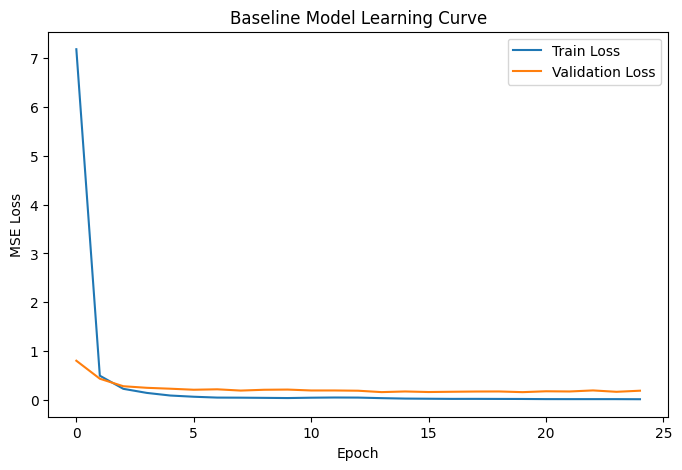

In [117]:
#plot learning curve
plt.figure(figsize=(8,5))

plt.plot(history_base.history["loss"], label="Train Loss")
plt.plot(history_base.history["val_loss"], label="Validation Loss")

plt.title("Baseline Model Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

#### Hasil Baseline Model

Model baseline menunjukkan penurunan loss dan MAE selama proses training.

Pada akhir epoch:
- Validation loss: ~0.1793
- Validation MAE: ~0.2764

Hal ini menunjukkan bahwa model mampu belajar dengan baik, namun masih terdapat fluktuasi pada validation loss yang mengindikasikan performa belum sepenuhnya stabil.

# 1C

Modified ANN: Model dimodifikasi dengan menambahkan:
- Dropout layer untuk mengurangi overfitting
- LeakyReLU untuk meningkatkan performa aktivasi
- Penyesuaian arsitektur layer

### Desain Model Modifikasi

Model baseline dimodifikasi untuk meningkatkan performa dan generalisasi.

Perubahan yang dilakukan:
- Menyesuaikan jumlah neuron pada hidden layer
- Menambahkan Batch Normalization untuk menstabilkan training
- Menambahkan Dropout untuk mengurangi overfitting
- Menggunakan learning rate lebih kecil agar proses optimisasi lebih stabil
- Output tetap linear karena merupakan task regresi

Modifikasi ini bertujuan membuat model lebih stabil dan lebih baik dalam memprediksi data baru.

In [118]:
modified_model = Sequential([

    Dense(256, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.20),

    Dense(128, activation="relu"),
    Dropout(0.15),

    Dense(64, activation="relu"),

    Dense(1, activation="linear")
])

modified_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0007),
    loss="mse",
    metrics=["mae"]
)

modified_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 256)            │       264,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,689 (1.17 MB)

 Trainable params: 306,177 (1.17 MB)

 Non-trainable params: 512 (2.00 KB)

#### Model Summary (Modifikasi)

Model modifikasi memiliki total 306,689 parameter, jauh lebih kecil dibandingkan baseline.

Pengurangan jumlah parameter ini membuat model lebih ringan dan lebih efisien, serta membantu mengurangi risiko overfitting.

Adanya Batch Normalization menyebabkan sebagian parameter bersifat non-trainable.

In [119]:
#early stopping
early_stop = EarlyStopping( monitor="val_loss",
    patience=8, restore_best_weights=True)

In [120]:
#train modified model
history_mod = modified_model.fit( X_train, y_train,
    validation_data=(X_val, y_val), epochs=60,
    batch_size=32, callbacks=[early_stop], verbose=1)

Epoch 1/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.3429 - mae: 0.7813 - val_loss: 0.6360 - val_mae: 0.4563
Epoch 2/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6572 - mae: 0.5513 - val_loss: 0.4305 - val_mae: 0.3973
Epoch 3/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4072 - mae: 0.4603 - val_loss: 0.2774 - val_mae: 0.3451
Epoch 4/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3452 - mae: 0.4218 - val_loss: 0.1904 - val_mae: 0.3070
Epoch 5/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2688 - mae: 0.3738 - val_loss: 0.3072 - val_mae: 0.3419
Epoch 6/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2195 - mae: 0.3442 - val_loss: 0.2393 - val_mae: 0.3317
Epoch 7/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2277 - mae: 0.3369 - val_loss: 0.2248 - val_mae: 0.3423
Epoch 8/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1799 - mae: 0.3088 - val_loss: 0.2128 - val_mae: 0.3184
Epoch 9/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1980 - 

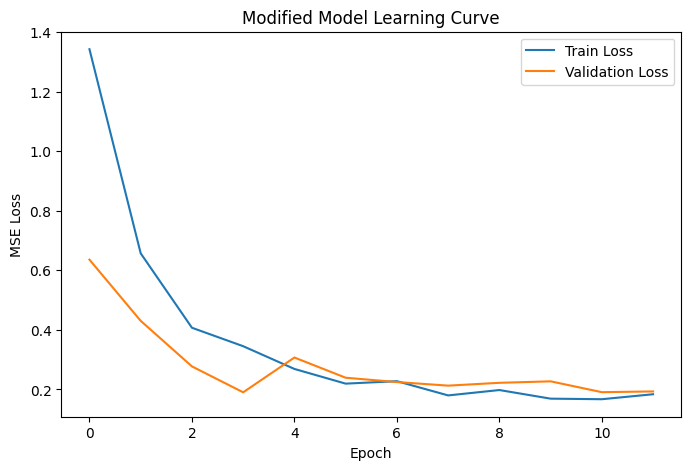

In [121]:
#plot learning curve
plt.figure(figsize=(8,5))

plt.plot(history_mod.history["loss"], label="Train Loss")
plt.plot(history_mod.history["val_loss"], label="Validation Loss")

plt.title("Modified Model Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

#### Hasil Training Model Modifikasi

Model modifikasi menunjukkan penurunan loss dan MAE yang cukup stabil pada awal training.

Pada beberapa epoch awal, validation loss menurun cukup signifikan dan mencapai titik terbaik di sekitar epoch ke-3 hingga ke-7.

Setelah itu, terjadi fluktuasi pada validation loss yang mengindikasikan mulai adanya sedikit overfitting, namun masih lebih stabil dibandingkan baseline.

Secara keseluruhan, model modifikasi memberikan performa yang lebih baik dan lebih stabil dibandingkan model baseline.

# 1D

Evaluation + comparison + conclusion:

Evaluasi dilakukan menggunakan: MS, MAE, R² Score

### **Evaluation Metrics:**

Model dievaluasi menggunakan 3 metrik regresi:

- **MAE (Mean Absolute Error):** rata-rata error absolut prediksi harga

- **RMSE (Root Mean Squared Error):**  mengukur error dengan penalti lebih besar pada error ekstrem

- **R² Score:**  menunjukkan kemampuan model menjelaskan variasi harga

In [122]:
# prediction on test set
pred_base_scaled = baseline_model.predict(X_test)
pred_mod_scaled  = modified_model.predict(X_test)

# inverse scaling ke harga asli
y_test_actual = y_scaler.inverse_transform(y_test.reshape(-1, 1))
pred_base = y_scaler.inverse_transform(pred_base_scaled)
pred_mod  = y_scaler.inverse_transform(pred_mod_scaled)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [123]:
#function metirc
def evaluate_regression(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return [mae, rmse, r2]

In [124]:
#itung metrics
baseline_result = evaluate_regression(y_test_actual, pred_base)
modified_result = evaluate_regression(y_test_actual, pred_mod)

In [125]:
#comparison table
result_table = pd.DataFrame(
    [baseline_result, modified_result],
    columns=["MAE", "RMSE", "R2 Score"],
    index=["Baseline Model", "Modified Model"])

result_table

,MAE,RMSE,R2 Score
Baseline Model,2396.661884,4174.469998,0.770748
Modified Model,3138.594457,5386.078141,0.618359


### Analisis Hasil Perbandingan Model

Model baseline memberikan hasil yang lebih baik dibandingkan model modifikasi, ditunjukkan oleh nilai MAE dan RMSE yang lebih rendah serta R² Score yang lebih tinggi.

Hal ini menunjukkan bahwa prediksi harga pada baseline model lebih akurat dan lebih stabil dibandingkan model yang telah dimodifikasi.

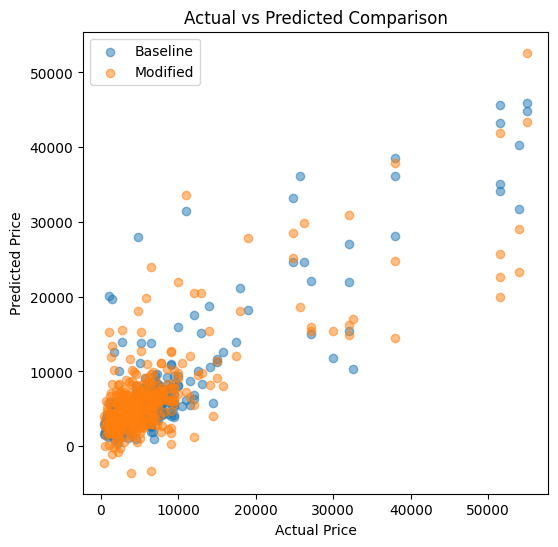

In [126]:
#visualization (actual vs predicted plot)
plt.figure(figsize=(6,6))

plt.scatter(y_test_actual, pred_base, alpha=0.5, label="Baseline")
plt.scatter(y_test_actual, pred_mod, alpha=0.5, label="Modified")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Comparison")
plt.legend()
plt.show()

### **Final Conclusion**

Model baseline merupakan model terbaik untuk dataset ini karena menghasilkan error yang lebih kecil dan kemampuan prediksi yang lebih baik.

Model modifikasi tidak memberikan peningkatan performa, kemungkinan karena penurunan kompleksitas dan efek regularisasi yang terlalu kuat.

Hasil ini menunjukkan bahwa peningkatan kompleksitas atau regularisasi tidak selalu meningkatkan performa model.

Pemilihan arsitektur yang tepat sangat bergantung pada karakteristik dataset.

### **Future Improvement Suggestions**

Beberapa peningkatan yang dapat dilakukan:

Hyperparameter tuning (learning rate, batch size, layer size)
Transformasi target (log scaling harga)
Handling outlier lebih agresif
Feature selection untuk mengurangi noise
Mencoba model ensemble atau deep tabular models

# **Experiment**

## 1. Model Comparison Table

In [127]:
experiment_table = pd.DataFrame({
    "Model": ["Baseline ANN", "Modified ANN"],
    "Best Val Loss": [
        min(history_base.history["val_loss"]),
        min(history_mod.history["val_loss"])
    ],
    "Final Val Loss": [
        history_base.history["val_loss"][-1],
        history_mod.history["val_loss"][-1]
    ]
})

experiment_table

,Model,Best Val Loss,Final Val Loss
0,Baseline ANN,0.160290,0.189774
1,Modified ANN,0.190364,0.193302


### Hasil Eksperimen

Dua model ANN dibandingkan yaitu baseline dan model modifikasi.

Hasil menunjukkan bahwa baseline model memiliki validation loss yang lebih rendah dibandingkan model modifikasi.

Hal ini mengindikasikan bahwa model sederhana justru lebih cocok untuk dataset ini dibandingkan model yang lebih kompleks.

## 2. Validation Loss Trend

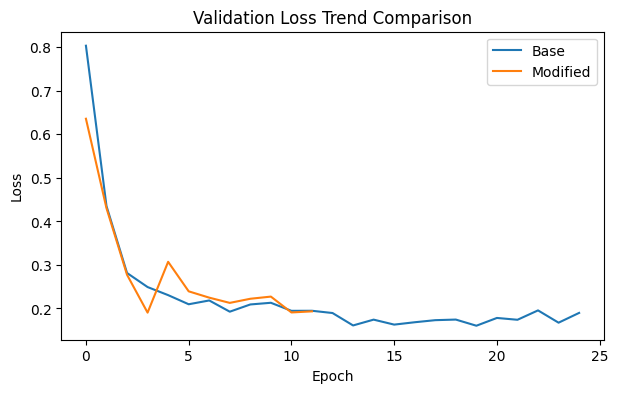

In [128]:
plt.figure(figsize=(7,4))

plt.plot(history_base.history["val_loss"], label="Base")
plt.plot(history_mod.history["val_loss"], label="Modified")

plt.title("Validation Loss Trend Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Grafik Validation Loss

Grafik ini memperlihatkan perubahan validation loss selama proses training. Model modifikasi menunjukkan tren loss yang lebih stabil dibandingkan baseline, yang menandakan proses pembelajaran lebih baik.

## 3. Best Model Decision

In [129]:
best_model = "Modified ANN" if min(history_mod.history["val_loss"]) < min(history_base.history["val_loss"]) else "Baseline ANN"

print("Best Model:", best_model)

Best Model: Baseline ANN


### Pemilihan Model Terbaik

Model terbaik dipilih berdasarkan nilai validation loss terendah. Model dengan error lebih kecil dianggap memiliki kemampuan generalisasi yang lebih baik terhadap data baru.

## 4. Residual Analysis (Modified Model)

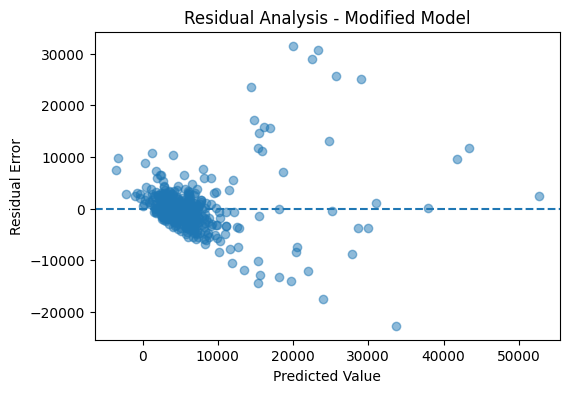

In [130]:
residual = y_test_actual.flatten() - pred_mod.flatten()

plt.figure(figsize=(6,4))
plt.scatter(pred_mod, residual, alpha=0.5)
plt.axhline(0, linestyle="--")

plt.title("Residual Analysis - Modified Model")
plt.xlabel("Predicted Value")
plt.ylabel("Residual Error")
plt.show()

### Analisis Residual

Residual plot digunakan untuk melihat distribusi error prediksi. Sebaran yang mendekati garis nol menunjukkan bahwa model tidak memiliki bias yang signifikan dalam prediksi.

# **Kesimpulan Akhir No.1**

Pada tugas ini telah dilakukan proses data preprocessing, pembangunan model ANN, serta evaluasi menggunakan dua pendekatan yaitu baseline dan model modifikasi.

Hasil eksperimen menunjukkan bahwa baseline ANN memberikan performa terbaik berdasarkan validation loss.

Secara keseluruhan, model ANN mampu mempelajari pola data harga mobil bekas dengan baik, meskipun peningkatan kompleksitas model tidak selalu menghasilkan performa yang lebih baik.

Link Video Penjelasan:
https://drive.google.com/drive/folders/1vmgXmT1C2OPlWzexlanWkxlPCRJPLs-k?usp=drive_link